In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
df = pd.read_csv('car_fuel_efficiency.csv')

columns = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']
df = df[columns]
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,170,159.0,3413.433759,2003,13.231729
1,130,97.0,3149.664934,2007,13.688217
2,170,78.0,3079.038997,2018,14.246341
3,220,NaN,2542.392402,2009,16.912736
4,210,140.0,3460.870990,2009,12.488369


## EDA

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

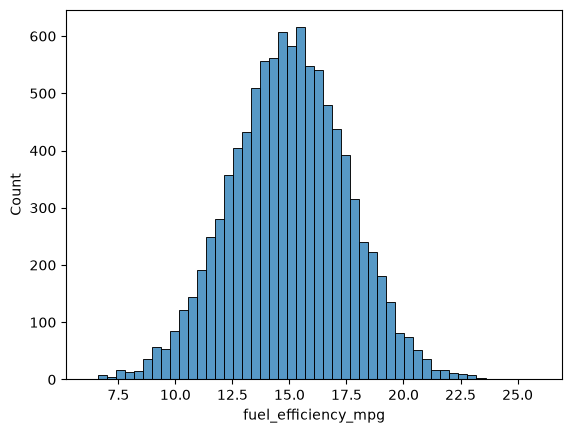

In [37]:
sns.histplot(df['fuel_efficiency_mpg'], bins=50)

## Q1. Missing values

In [38]:
df.isnull().sum()

engine_displacement      0
horsepower             708
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

## Q2. Median horsepower

In [39]:
df['horsepower'].median()

np.float64(149.0)

## Prepare and split the dataset

In [40]:
def split_data(df, seed):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    idx = np.arange(n)
    np.random.seed(seed)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
    df_val = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)
    df_test = df.iloc[idx[n_train + n_val:]].reset_index(drop=True)

    y_train = df_train['fuel_efficiency_mpg'].values
    y_val = df_val['fuel_efficiency_mpg'].values
    y_test = df_test['fuel_efficiency_mpg'].values

    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']

    return df_train, df_val, df_test, y_train, y_val, y_test

In [41]:
df_train, df_val, df_test, y_train, y_val, y_test = split_data(df, seed=42)
len(df_train), len(df_val), len(df_test)

(5824, 1940, 1940)

## Linear regression and RMSE

In [42]:
def train_linear_regression(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T @ X
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv @ X.T @ y

    return w_full[0], w_full[1:]


def rmse(y, y_pred):
    error = y - y_pred
    return np.sqrt((error ** 2).mean())

## Q3. Fill with 0 or with mean

In [43]:
mean_hp = df_train['horsepower'].mean()

for name, fill_value in [('zero', 0), ('mean', mean_hp)]:
    X_train = df_train.fillna(fill_value).values
    X_val = df_val.fillna(fill_value).values

    w0, w = train_linear_regression(X_train, y_train)
    y_pred = w0 + X_val @ w

    print(name, round(rmse(y_val, y_pred), 2))

zero 0.52
mean 0.46


## Q4. Regularization

In [44]:
X_train = df_train.fillna(0).values
X_val = df_val.fillna(0).values

for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression(X_train, y_train, r=r)
    y_pred = w0 + X_val @ w

    print(r, round(rmse(y_val, y_pred), 2))

0 0.52
0.01 0.52
0.1 0.52
1 0.52
5 0.52
10 0.52
100 0.52


## Q5. Seed influence

In [45]:
scores = []

for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    df_train, df_val, df_test, y_train, y_val, y_test = split_data(df, seed=seed)

    X_train = df_train.fillna(0).values
    X_val = df_val.fillna(0).values

    w0, w = train_linear_regression(X_train, y_train)
    y_pred = w0 + X_val @ w

    scores.append(rmse(y_val, y_pred))

round(np.std(scores), 3)

np.float64(0.007)

## Q6. Final model on test

In [46]:
df_train, df_val, df_test, y_train, y_val, y_test = split_data(df, seed=9)

df_full_train = pd.concat([df_train, df_val]).reset_index(drop=True)
y_full_train = np.concatenate([y_train, y_val])

X_full_train = df_full_train.fillna(0).values
X_test = df_test.fillna(0).values

w0, w = train_linear_regression(X_full_train, y_full_train, r=0.001)
y_pred = w0 + X_test @ w

rmse(y_test, y_pred)

np.float64(0.5156261299166541)